In [1]:
from pathlib import Path
import pandas as pd

from data import BasinDataLake

save_dir = Path("/nas/cee-water/cjgleason/ted/swot-ml/data/reservoirs")

root_dir = save_dir / 'datalakes' / 'training'
store = BasinDataLake(root_dir)

In [ ]:
zarr_path = '/work/pi_cjgleason_umass_edu/ted/swot-ml-zarr'
store.export_to_zarr(zarr_path, start_date='1980-01-01')

No new basins to process for source: glow-s.
No new basins to process for source: gauge.
Processing source: era5.


Iterating through basins:   0%|          | 0/2 [00:00<?, ?it/s]

In [3]:
import xarray as xr

ds = xr.open_dataset(
    "/work/pi_cjgleason_umass_edu/ted/swot-ml-zarr/era5/UKEA-520894",
    engine="zarr",
)

ds

/tmp/ipykernel_2699016/600448179.py:3: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  ds = xr.open_dataset(


<xarray.Dataset> Size: 42MB
Dimensions:    (date: 16437, subbasin: 16)
Coordinates:
  * date       (date) datetime64[ns] 131kB 1980-01-01 1980-01-02 ... 2024-12-31
  * subbasin   (subbasin) object 128B '23009239' '23009242' ... 'UKEA-520894'
Data variables: (12/20)
    d2m_var    (date, subbasin) float64 2MB ...
    e_mean     (date, subbasin) float64 2MB ...
    e_var      (date, subbasin) float64 2MB ...
    fal_var    (date, subbasin) float64 2MB ...
    fal_mean   (date, subbasin) float64 2MB ...
    d2m_mean   (date, subbasin) float64 2MB ...
    ...         ...
    sro_var    (date, subbasin) float64 2MB ...
    strd_mean  (date, subbasin) float64 2MB ...
    t2m_mean   (date, subbasin) float64 2MB ...
    t2m_var    (date, subbasin) float64 2MB ...
    tp_mean    (date, subbasin) float64 2MB ...
    tp_var     (date, subbasin) float64 2MB ...

In [15]:
import numpy as np

np.isnan(ds['e_mean'].values).any()

False

In [18]:
list(ds.data_vars)

['d2m_var',
 'e_mean',
 'e_var',
 'fal_var',
 'fal_mean',
 'd2m_mean',
 'sp_mean',
 'ro_mean',
 'ro_var',
 'sp_var',
 'sro_mean',
 'strd_var',
 'ssrd_var',
 'ssrd_mean',
 'sro_var',
 'strd_mean',
 't2m_mean',
 't2m_var',
 'tp_mean',
 'tp_var']

In [53]:
time_gaps = {
    column: ds[[column]].to_array().isnull().any().item()
    for column in list(ds.data_vars)
}
time_gaps

{'d2m_var': False,
 'e_mean': False,
 'e_var': False,
 'fal_var': False,
 'fal_mean': False,
 'd2m_mean': False,
 'sp_mean': False,
 'ro_mean': False,
 'ro_var': False,
 'sp_var': False,
 'sro_mean': False,
 'strd_var': False,
 'ssrd_var': False,
 'ssrd_mean': False,
 'sro_var': False,
 'strd_mean': False,
 't2m_mean': False,
 't2m_var': False,
 'tp_mean': False,
 'tp_var': False}

In [51]:
ds

<xarray.Dataset> Size: 42MB
Dimensions:    (date: 16437, subbasin: 16)
Coordinates:
  * date       (date) datetime64[ns] 131kB 1980-01-01 1980-01-02 ... 2024-12-31
  * subbasin   (subbasin) object 128B '23009239' '23009242' ... 'UKEA-520894'
Data variables: (12/20)
    d2m_var    (date, subbasin) float64 2MB 0.001267 0.0 ... 0.005051 0.004444
    e_mean     (date, subbasin) float64 2MB -0.0001302 -7.779e-05 ... -0.0003217
    e_var      (date, subbasin) float64 2MB 1.832e-09 0.0 ... 5.054e-10
    fal_var    (date, subbasin) float64 2MB 1.858e-06 0.0 ... 2.354e-06
    fal_mean   (date, subbasin) float64 2MB 0.1623 0.164 ... 0.1602 0.1596
    d2m_mean   (date, subbasin) float64 2MB 272.3 272.2 272.0 ... 280.0 280.1
    ...         ...
    sro_var    (date, subbasin) float64 2MB 1.825e-16 0.0 ... 3.213e-14
    strd_mean  (date, subbasin) float64 2MB 2.136e+07 2.117e+07 ... 2.682e+07
    t2m_mean   (date, subbasin) float64 2MB 273.3 273.3 272.5 ... 282.2 282.6
    t2m_var    (date, subbasin) float64 2MB 0.005305 0.0 ... 0.00852 0.001825
    tp_mean    (date, subbasin) float64 2MB 2.808e-06 2.583e-06 ... 7.735e-05
    tp_var     (date, subbasin) float64 2MB 2.618e-14 0.0 ... 1.871e-10

In [42]:
ds.isnull().any().any().values()

ValuesView(<xarray.Dataset> Size: 20B
Dimensions:    ()
Data variables: (12/20)
    d2m_var    bool 1B False
    e_mean     bool 1B False
    e_var      bool 1B False
    fal_var    bool 1B False
    fal_mean   bool 1B False
    d2m_mean   bool 1B False
    ...         ...
    sro_var    bool 1B False
    strd_mean  bool 1B False
    t2m_mean   bool 1B False
    t2m_var    bool 1B False
    tp_mean    bool 1B False
    tp_var     bool 1B False)

In [20]:
p = Path(zarr_path)
groups = [d.name for d in p.iterdir() if d.is_dir()]
print(f"Discovered groups: {groups}")
group_datasets = [xr.open_zarr(p / g) for g in groups]
ds = xr.merge(group_datasets)
ds


Discovered groups: ['era5', 'gauge']


/tmp/ipykernel_3541392/3750044157.py:4: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  group_datasets = [xr.open_zarr(p / g) for g in groups]
/tmp/ipykernel_3541392/3750044157.py:4: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to

<xarray.Dataset> Size: 66MB
Dimensions:    (date: 24451, subbasin: 16)
Coordinates:
  * date       (date) datetime64[ns] 196kB 1952-03-31 1952-04-01 ... 2025-09-07
  * subbasin   (subbasin) object 128B '56150341' '56150344' ... 'ABOM-97444010'
Data variables: (12/21)
    fal_mean   (date, subbasin) float64 3MB dask.array<chunksize=(89, 16), meta=np.ndarray>
    d2m_var    (date, subbasin) float64 3MB dask.array<chunksize=(89, 16), meta=np.ndarray>
    fal_var    (date, subbasin) float64 3MB dask.array<chunksize=(89, 16), meta=np.ndarray>
    e_mean     (date, subbasin) float64 3MB dask.array<chunksize=(89, 16), meta=np.ndarray>
    ro_mean    (date, subbasin) float64 3MB dask.array<chunksize=(89, 16), meta=np.ndarray>
    d2m_mean   (date, subbasin) float64 3MB dask.array<chunksize=(89, 16), meta=np.ndarray>
    ...         ...
    t2m_mean   (date, subbasin) float64 3MB dask.array<chunksize=(89, 16), meta=np.ndarray>
    strd_var   (date, subbasin) float64 3MB dask.array<chunksize=(89, 16), meta=np.ndarray>
    tp_mean    (date, subbasin) float64 3MB dask.array<chunksize=(89, 16), meta=np.ndarray>
    t2m_var    (date, subbasin) float64 3MB dask.array<chunksize=(89, 16), meta=np.ndarray>
    tp_var     (date, subbasin) float64 3MB dask.array<chunksize=(89, 16), meta=np.ndarray>
    discharge  (date, subbasin) float64 3MB dask.array<chunksize=(90, 5), meta=np.ndarray>

In [19]:
group_datasets[1]

<xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*

In [8]:
import xarray as xr 

zarr_path = '/work/pi_cjgleason_umass_edu/ted/swot-ml-zarr'
ds_gauge = xr.open_zarr(zarr_path, group='era5')
ds_gauge

<xarray.Dataset> Size: 42MB
Dimensions:    (date: 16437, subbasin: 16)
Coordinates:
  * date       (date) datetime64[ns] 131kB 1980-01-01 1980-01-02 ... 2024-12-31
  * subbasin   (subbasin) object 128B '56150341' '56150344' ... 'ABOM-97444010'
Data variables: (12/20)
    d2m_mean   (date, subbasin) float64 2MB dask.array<chunksize=(90, 16), meta=np.ndarray>
    d2m_var    (date, subbasin) float64 2MB dask.array<chunksize=(90, 16), meta=np.ndarray>
    e_mean     (date, subbasin) float64 2MB dask.array<chunksize=(90, 16), meta=np.ndarray>
    e_var      (date, subbasin) float64 2MB dask.array<chunksize=(90, 16), meta=np.ndarray>
    fal_mean   (date, subbasin) float64 2MB dask.array<chunksize=(90, 16), meta=np.ndarray>
    fal_var    (date, subbasin) float64 2MB dask.array<chunksize=(90, 16), meta=np.ndarray>
    ...         ...
    strd_mean  (date, subbasin) float64 2MB dask.array<chunksize=(90, 16), meta=np.ndarray>
    strd_var   (date, subbasin) float64 2MB dask.array<chunksize=(90, 16), meta=np.ndarray>
    t2m_mean   (date, subbasin) float64 2MB dask.array<chunksize=(90, 16), meta=np.ndarray>
    t2m_var    (date, subbasin) float64 2MB dask.array<chunksize=(90, 16), meta=np.ndarray>
    tp_mean    (date, subbasin) float64 2MB dask.array<chunksize=(90, 16), meta=np.ndarray>
    tp_var     (date, subbasin) float64 2MB dask.array<chunksize=(90, 16), meta=np.ndarray>

In [9]:
# Example: Select a 15-day period 
start_slice = '1990-06-01'
end_slice = '1990-06-15'

# .sel() is the standard way to perform label-based selection
data_slice = ds_gauge.sel(
    date=slice(start_slice, end_slice),
)
data_slice

<xarray.Dataset> Size: 39kB
Dimensions:    (date: 15, subbasin: 16)
Coordinates:
  * date       (date) datetime64[ns] 120B 1990-06-01 1990-06-02 ... 1990-06-15
  * subbasin   (subbasin) object 128B '56150341' '56150344' ... 'ABOM-97444010'
Data variables: (12/20)
    d2m_mean   (date, subbasin) float64 2kB dask.array<chunksize=(15, 16), meta=np.ndarray>
    d2m_var    (date, subbasin) float64 2kB dask.array<chunksize=(15, 16), meta=np.ndarray>
    e_mean     (date, subbasin) float64 2kB dask.array<chunksize=(15, 16), meta=np.ndarray>
    e_var      (date, subbasin) float64 2kB dask.array<chunksize=(15, 16), meta=np.ndarray>
    fal_mean   (date, subbasin) float64 2kB dask.array<chunksize=(15, 16), meta=np.ndarray>
    fal_var    (date, subbasin) float64 2kB dask.array<chunksize=(15, 16), meta=np.ndarray>
    ...         ...
    strd_mean  (date, subbasin) float64 2kB dask.array<chunksize=(15, 16), meta=np.ndarray>
    strd_var   (date, subbasin) float64 2kB dask.array<chunksize=(15, 16), meta=np.ndarray>
    t2m_mean   (date, subbasin) float64 2kB dask.array<chunksize=(15, 16), meta=np.ndarray>
    t2m_var    (date, subbasin) float64 2kB dask.array<chunksize=(15, 16), meta=np.ndarray>
    tp_mean    (date, subbasin) float64 2kB dask.array<chunksize=(15, 16), meta=np.ndarray>
    tp_var     (date, subbasin) float64 2kB dask.array<chunksize=(15, 16), meta=np.ndarray>

In [10]:
data_slice.load()

<xarray.Dataset> Size: 39kB
Dimensions:    (date: 15, subbasin: 16)
Coordinates:
  * date       (date) datetime64[ns] 120B 1990-06-01 1990-06-02 ... 1990-06-15
  * subbasin   (subbasin) object 128B '56150341' '56150344' ... 'ABOM-97444010'
Data variables: (12/20)
    d2m_mean   (date, subbasin) float64 2kB 279.2 279.0 278.8 ... 278.4 278.6
    d2m_var    (date, subbasin) float64 2kB 0.01646 0.02721 ... 0.02803 0.01608
    e_mean     (date, subbasin) float64 2kB -0.001143 -0.001145 ... -0.001147
    e_var      (date, subbasin) float64 2kB 2.066e-09 1.525e-09 ... 7.015e-09
    fal_mean   (date, subbasin) float64 2kB 0.1097 0.123 0.136 ... 0.1233 0.1059
    fal_var    (date, subbasin) float64 2kB 3e-05 7.267e-05 ... 5.888e-05
    ...         ...
    strd_mean  (date, subbasin) float64 2kB 2.798e+07 2.798e+07 ... 2.582e+07
    strd_var   (date, subbasin) float64 2kB 4.48e+10 1.673e+10 ... 6.207e+10
    t2m_mean   (date, subbasin) float64 2kB 283.9 283.6 283.8 ... 282.1 282.1
    t2m_var    (date, subbasin) float64 2kB 0.02642 0.0006931 ... 0.04429
    tp_mean    (date, subbasin) float64 2kB 0.0 0.0 0.0 ... 0.001239 0.0005554
    tp_var     (date, subbasin) float64 2kB 0.0 0.0 0.0 ... 1.649e-07 1.584e-08

In [12]:
tmp.index.get_level_values('date').tz_localize(None)

DatetimeIndex(['1952-03-31', '1952-04-01', '1952-04-02', '1952-04-03',
               '1952-04-04', '1952-04-05', '1952-04-06', '1952-05-27',
               '1952-05-30', '1952-05-31',
               ...
               '2025-09-06', '2025-09-06', '2025-09-06', '2025-09-06',
               '2025-09-06', '2025-09-07', '2025-09-07', '2025-09-07',
               '2025-09-07', '2025-09-07'],
              dtype='datetime64[us]', name='date', length=83524, freq=None)

In [2]:
def read_file(fp):
    with open(fp, "r") as file:
        basin_list = file.readlines()
        basin_list = [basin.strip() for basin in basin_list]
    return basin_list

list_dir = save_dir.parent / 'multigraph' / 'basin_lists'
train_basins = read_file(list_dir / 'proto_train.txt')
test_basins = read_file(list_dir / 'proto_test.txt')

In [14]:
static_df = store.read_static()


subbasins = (
    static_df.loc[static_df["basin"] == basin, "subbasin"]
    .astype(str)
    .unique()
    .tolist()
)
subbasins = sorted(subbasins)
subbasins

['ABOM-100288010',
 'ABOM-101896010',
 'ABOM-102903010',
 'ABOM-102984010',
 'ABOM-97444010']

In [16]:
df = tmp
value_cols = [c for c in df.columns if c not in ["basin", "year"]]
value_cols

['discharge', 'quality_flag', 'provider']

In [17]:
import xarray as xr
ds_xr = xr.Dataset.from_dataframe(df)
ds_xr

<xarray.Dataset> Size: 5MB
Dimensions:       (date: 24451, subbasin: 5)
Coordinates:
  * date          (date) datetime64[us, UTC] 196kB 1952-03-31 00:00:00+00:00 ...
  * subbasin      (subbasin) object 40B 'ABOM-100288010' ... 'ABOM-97444010'
Data variables:
    discharge     (date, subbasin) float64 978kB nan nan nan ... 6.508 4.7 7.828
    quality_flag  (date, subbasin) object 978kB nan nan ... 'unknown' 'unknown'
    provider      (date, subbasin) object 978kB nan nan nan ... 'ABOM' 'ABOM'
    basin         (date, subbasin) object 978kB nan nan ... 'ABOM-100288010'
    year          (date, subbasin) float64 978kB nan nan ... 2.025e+03 2.025e+03

In [18]:
ds_xr.reindex(subbasin=subbasins)

<xarray.Dataset> Size: 5MB
Dimensions:       (date: 24451, subbasin: 5)
Coordinates:
  * date          (date) datetime64[us, UTC] 196kB 1952-03-31 00:00:00+00:00 ...
  * subbasin      (subbasin) object 40B 'ABOM-100288010' ... 'ABOM-97444010'
Data variables:
    discharge     (date, subbasin) float64 978kB nan nan nan ... 6.508 4.7 7.828
    quality_flag  (date, subbasin) object 978kB nan nan ... 'unknown' 'unknown'
    provider      (date, subbasin) object 978kB nan nan nan ... 'ABOM' 'ABOM'
    basin         (date, subbasin) object 978kB nan nan ... 'ABOM-100288010'
    year          (date, subbasin) float64 978kB nan nan ... 2.025e+03 2.025e+03

In [4]:
import dask.dataframe as dd
dd.from_pyarrow_dataset(pyarrow_dataset)

AttributeError: module 'dask.dataframe' has no attribute 'from_pyarrow_dataset'

In [9]:
pa.fragments

AttributeError: 'pyarrow._dataset.FileSystemDataset' object has no attribute 'fragments'

In [6]:
tmp = store.read_dynamic(train_basins[-1], start_date = '2024-01-01', end_date = '2024-02-01')
tmp

source                                      glow-s       gauge               \
variable                                glow_width   discharge quality_flag   
subbasin      date                                                            
USGS-02109500 2024-01-01 00:00:00+00:00        NaN   57.766367         good   
USGS-02110550 2024-01-01 00:00:00+00:00        NaN  150.645624         good   
USGS-02110500 2024-01-01 00:00:00+00:00        NaN  140.168391         good   
USGS-02110704 2024-01-01 00:00:00+00:00        NaN  151.495129         good   
USGS-02109500 2024-01-02 00:00:00+00:00        NaN   54.085177         good   
...                                            ...         ...          ...   
73012405      2024-01-31 00:00:00+00:00        NaN         NaN          NaN   
73013273      2024-02-01 00:00:00+00:00        NaN         NaN          NaN   
73013531      2024-02-01 00:00:00+00:00        NaN         NaN          NaN   
73012123      2024-02-01 00:00:00+00:00        NaN         NaN          NaN   
73012405      2024-02-01 00:00:00+00:00        NaN         NaN          NaN   

source                                           swot-river              \
variable                                provider  wse_river wse_u_river   
subbasin      date                                                        
USGS-02109500 2024-01-01 00:00:00+00:00     USGS        NaN         NaN   
USGS-02110550 2024-01-01 00:00:00+00:00     USGS        NaN         NaN   
USGS-02110500 2024-01-01 00:00:00+00:00     USGS        NaN         NaN   
USGS-02110704 2024-01-01 00:00:00+00:00     USGS        NaN         NaN   
USGS-02109500 2024-01-02 00:00:00+00:00     USGS        NaN         NaN   
...                                          ...        ...         ...   
73012405      2024-01-31 00:00:00+00:00      NaN        NaN         NaN   
73013273      2024-02-01 00:00:00+00:00      NaN        NaN         NaN   
73013531      2024-02-01 00:00:00+00:00      NaN        NaN         NaN   
73012123      2024-02-01 00:00:00+00:00      NaN        NaN         NaN   
73012405      2024-02-01 00:00:00+00:00      NaN        NaN         NaN   

source                                                             \
variable                                wse_r_u_river slope_river   
subbasin      date                                                  
USGS-02109500 2024-01-01 00:00:00+00:00           NaN         NaN   
USGS-02110550 2024-01-01 00:00:00+00:00           NaN         NaN   
USGS-02110500 2024-01-01 00:00:00+00:00           NaN         NaN   
USGS-02110704 2024-01-01 00:00:00+00:00           NaN         NaN   
USGS-02109500 2024-01-02 00:00:00+00:00           NaN         NaN   
...                                               ...         ...   
73012405      2024-01-31 00:00:00+00:00           NaN         NaN   
73013273      2024-02-01 00:00:00+00:00           NaN         NaN   
73013531      2024-02-01 00:00:00+00:00           NaN         NaN   
73012123      2024-02-01 00:00:00+00:00           NaN         NaN   
73012405      2024-02-01 00:00:00+00:00           NaN         NaN   

source                                                                 ...  \
variable                                slope_u_river slope_r_u_river  ...   
subbasin      date                                                     ...   
USGS-02109500 2024-01-01 00:00:00+00:00           NaN             NaN  ...   
USGS-02110550 2024-01-01 00:00:00+00:00           NaN             NaN  ...   
USGS-02110500 2024-01-01 00:00:00+00:00           NaN             NaN  ...   
USGS-02110704 2024-01-01 00:00:00+00:00           NaN             NaN  ...   
USGS-02109500 2024-01-02 00:00:00+00:00           NaN             NaN  ...   
...                                               ...             ...  ...   
73012405      2024-01-31 00:00:00+00:00           NaN             NaN  ...   
73013273      2024-02-01 00:00:00+00:00           NaN             NaN  ...   
73013531      202

In [7]:
for col in tmp.columns:
    print(f"{col}: {tmp[col].dtype}")

('glow-s', 'glow_width'): float64
('gauge', 'discharge'): float64
('gauge', 'quality_flag'): object
('gauge', 'provider'): object
('swot-river', 'wse_river'): float64
('swot-river', 'wse_u_river'): float64
('swot-river', 'wse_r_u_river'): float64
('swot-river', 'slope_river'): float64
('swot-river', 'slope_u_river'): float64
('swot-river', 'slope_r_u_river'): float64
('swot-river', 'slope2_river'): float64
('swot-river', 'slope2_u_river'): float64
('swot-river', 'slope2_r_u_river'): float64
('swot-river', 'width_river'): float64
('swot-river', 'width_u_river'): float64
('swot-river', 'area_total_river'): float64
('swot-river', 'area_tot_u_river'): float64
('swot-river', 'area_detct_river'): float64
('swot-river', 'area_det_u_river'): float64
('swot-river', 'area_wse_river'): float64
('swot-river', 'layovr_val_river'): float64
('swot-river', 'node_dist_river'): float64
('swot-river', 'loc_offset_river'): float64
('swot-river', 'xtrk_dist_river'): float64
('swot-river', 'reach_q_river'):

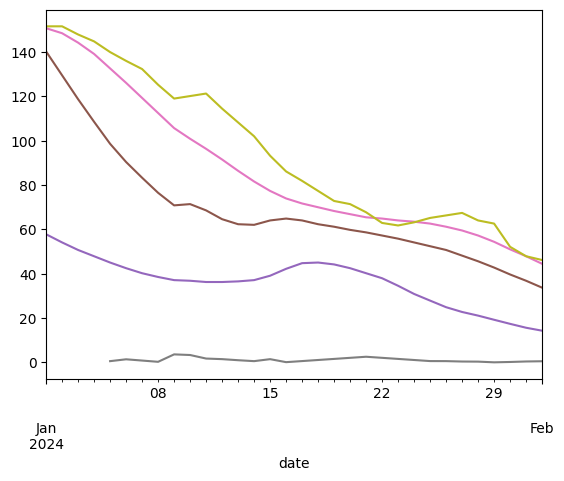

In [30]:
for idx, grp in tmp.groupby('subbasin'):
    grp.droplevel(0,0)['gauge']['discharge'].plot()